#Configuración y carga de datos

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


In [4]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
FIGURAS = '/content/drive/MyDrive/Tesis/figuras'
os.makedirs(FIGURAS, exist_ok=True)
import shap

from matplotlib.colors import LinearSegmentedColormap

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, precision_score, recall_score,
                             f1_score, accuracy_score, balanced_accuracy_score,
                             matthews_corrcoef, confusion_matrix, classification_report)

from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)

# Paleta y estilo, iguales a los del análisis exploratorio
AZUL    = '#1f4e79'
CELESTE = '#3d9ab8'
MARINO  = '#16324f'
TEAL    = '#2a6f6f'
GRAFITO = '#7d8b99'
NEUTRO  = '#4a5568'
TEXTO   = '#2d3748'

SEQ = LinearSegmentedColormap.from_list(
    'seq', ['#ffffff', '#dae3f0', '#a3bdd9', '#5b8bbf', '#1f4e79', '#12314a'])

COLOR_MODELO = {
    'Regresión logística': GRAFITO,
    'Random Forest': CELESTE,
    'CatBoost': MARINO,
}

mpl.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelcolor': TEXTO,
    'axes.edgecolor': '#c8cdd3',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#eceff2',
    'grid.linewidth': 0.7,
    'xtick.color': TEXTO,
    'ytick.color': TEXTO,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.frameon': False,
    'legend.fontsize': 9,
})

In [5]:
conn = sqlite3.connect('/content/drive/MyDrive/Tesis/FPA_FOD_20170508.sqlite')
df = pd.read_sql("SELECT * FROM Fires;", conn)
conn.close()

print(df.shape)

(1880465, 39)


Se importan las librerías de modelado y métricas, y se carga la tabla `Fires` completa
(1.880.465 registros). La semilla queda fija en 42 para que todos los resultados sean
reproducibles.

In [6]:
dfc = df[df['STAT_CAUSE_DESCR'] != 'Missing/Undefined'].copy()
dfc['ES_NATURAL'] = (dfc['STAT_CAUSE_DESCR'] == 'Lightning').astype(int)

NUM = ['FIRE_YEAR', 'DISCOVERY_DOY', 'LATITUDE', 'LONGITUDE', 'FIRE_SIZE']
CAT = ['STATE', 'OWNER_DESCR', 'NWCG_REPORTING_AGENCY']
FEATS = NUM + CAT

dfc = dfc[FEATS + ['ES_NATURAL']].copy()

print(f"Registros: {len(dfc):,}")
print(f"Naturales: {dfc['ES_NATURAL'].sum():,}  ({dfc['ES_NATURAL'].mean()*100:.2f}%)")
print(f"Antrópicos: {(1-dfc['ES_NATURAL']).sum():,}")

Registros: 1,713,742
Naturales: 278,468  (16.25%)
Antrópicos: 1,435,274


Se descartan los 166.723 registros sin causa reportada, porque no se conoce su etiqueta real.

La variable objetivo `ES_NATURAL` es binaria: vale 1 cuando la causa es Lightning (rayo,
la única causa natural del dataset) y 0 para las once causas antrópicas.

Se usan ocho variables predictoras: cinco numéricas (año, día del año, latitud, longitud y superficie quemada) y tres categóricas (estado, propietario del terreno y agencia reportante). Quedan fuera las columnas con más del 40% de valores faltantes, los identificadores y los códigos numéricos que duplican información ya presente.

#Esquema de validación


In [9]:
LOTES = [
    {'nombre': 'Lote 1', 'train_fin': 2001, 'test_ini': 2002, 'test_fin': 2004},
    {'nombre': 'Lote 2', 'train_fin': 2004, 'test_ini': 2005, 'test_fin': 2007},
    {'nombre': 'Lote 3', 'train_fin': 2007, 'test_ini': 2008, 'test_fin': 2011},
    {'nombre': 'Lote 4', 'train_fin': 2011, 'test_ini': 2012, 'test_fin': 2015},
]

for L in LOTES:
    tr_ = dfc[dfc['FIRE_YEAR'] <= L['train_fin']]
    te_ = dfc[(dfc['FIRE_YEAR'] >= L['test_ini']) & (dfc['FIRE_YEAR'] <= L['test_fin'])]
    print(f"{L['nombre']}:  train 1992-{L['train_fin']} ({len(tr_):>9,})   "
          f"test {L['test_ini']}-{L['test_fin']} ({len(te_):>8,})   "
          f"nat_train {tr_['ES_NATURAL'].mean():.3f}  nat_test {te_['ES_NATURAL'].mean():.3f}")

Lote 1:  train 1992-2001 (  699,265)   test 2002-2004 ( 197,579)   nat_train 0.169  nat_test 0.192
Lote 2:  train 1992-2004 (  896,844)   test 2005-2007 ( 261,543)   nat_train 0.174  nat_test 0.156
Lote 3:  train 1992-2007 (1,158,387)   test 2008-2011 ( 293,515)   nat_train 0.170  nat_test 0.143
Lote 4:  train 1992-2011 (1,451,902)   test 2012-2015 ( 261,840)   nat_train 0.164  nat_test 0.151


En lugar de una sola división entrenamiento/prueba uso validación temporal progresiva
(*walk-forward*): cada lote entrena con todos los años hasta un corte y evalúa sobre el bloque
de años siguiente.

| Lote | Entrenamiento | Prueba |
|---|---|---|
| 1 | 1992–2001 | 2002–2004 |
| 2 | 1992–2004 | 2005–2007 |
| 3 | 1992–2007 | 2008–2011 |
| 4 | 1992–2011 | 2012–2015 |

Con esto contesto dos cosas que una partición única no responde. La primera es si el
desempeño es estable o depende del corte que elegí: al tener cuatro mediciones me queda una
media y una dispersión, no un número suelto. La segunda es si la relación entre las variables
y la causa se mantiene en el tiempo o se degrada.

La división es temporal y no aleatoria porque los incendios tienen autocorrelación espacial y
temporal. Una partición al azar dejaría en el conjunto de prueba registros casi idénticos a
los de entrenamiento, del mismo estado, el mismo año y la misma agencia, y eso infla el
desempeño.

Scikit-learn tiene `TimeSeriesSplit`, que también respeta el orden temporal, pero corta en
tramos con la misma cantidad de registros. Acá los cortes son por bloques de años, y esos
bloques tienen volúmenes muy distintos, porque la cantidad de incendios registrados por año
crece a lo largo de la serie. Cortar por año hace que cada evaluación sea un período concreto,
que es la situación que quiero reproducir: entrenar con lo que ya pasó y predecir los años que
siguen.

In [10]:
def preparar(train_fin, test_ini, test_fin, val_anios=2):
    val_ini = train_fin - val_anios + 1
    tr = dfc[dfc['FIRE_YEAR'] <= train_fin - val_anios].copy()
    va = dfc[(dfc['FIRE_YEAR'] >= val_ini) & (dfc['FIRE_YEAR'] <= train_fin)].copy()
    te = dfc[(dfc['FIRE_YEAR'] >= test_ini) & (dfc['FIRE_YEAR'] <= test_fin)].copy()

    for c in NUM:
        med = tr[c].median()
        for d in (tr, va, te):
            d[c] = d[c].fillna(med)
    for c in CAT:
        for d in (tr, va, te):
            d[c] = d[c].fillna('Desconocido').astype(str)

    return tr, va, te


def umbral_optimo(y_val, p_val):
    prec, rec, umb = precision_recall_curve(y_val, p_val)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    return float(umb[np.nanargmax(f1[:-1])])


def metricas(y, p, umbral, modelo, lote):
    pred = (p >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    return {
        'Lote': lote,
        'Modelo': modelo,
        'AUC-ROC': roc_auc_score(y, p),
        'AUC-PR': average_precision_score(y, p),
        'Accuracy': accuracy_score(y, pred),
        'Bal.Acc': balanced_accuracy_score(y, pred),
        'Precision': precision_score(y, pred, zero_division=0),
        'Recall': recall_score(y, pred, zero_division=0),
        'Especif.': tn / (tn + fp),
        'F1': f1_score(y, pred, zero_division=0),
        'MCC': matthews_corrcoef(y, pred),
        'umbral': umbral,
    }

### Funciones auxiliares

`preparar` construye los tres conjuntos de cada lote. Dentro del período de entrenamiento
reservo los dos últimos años como conjunto de validación, que uso solo para fijar el umbral de
decisión. Así el conjunto de prueba no interviene en ninguna decisión previa a la evaluación
final. La imputación de faltantes, mediana para las numéricas y categoría *Desconocido* para
las categóricas, se calcula siempre sobre el entrenamiento y se aplica al resto, para no
filtrar información del futuro.

`umbral_optimo` elige el punto de corte que maximiza el F1 sobre la validación.

`metricas` calcula todos los indicadores de una vez, incluidos AUC-PR, exactitud balanceada y
MCC, que son los que tienen sentido con clases desbalanceadas.

# Modelos y entrenamiento

In [11]:
cat_idx = [FEATS.index(c) for c in CAT]

def pipe_sklearn(clf, escalar):
    return Pipeline([
        ('prep', ColumnTransformer([
            ('num', StandardScaler() if escalar else 'passthrough', NUM),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), CAT),
        ])),
        ('clf', clf),
    ])

MODELOS = {
    'Regresión logística': {
        'crear': lambda: pipe_sklearn(
            LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
            escalar=True),
        'submuestra': None,
    },
    'Random Forest': {
        'crear': lambda: pipe_sklearn(
            RandomForestClassifier(n_estimators=200, max_depth=18, min_samples_leaf=20,
                                   class_weight='balanced', random_state=SEED, n_jobs=-1),
            escalar=False),
        # (Falta hacer su prueba bien con el conjunto entero, gran posibilidad de
        # quedarme con CatBoost por comodidad)
        'submuestra': 0.30,
    },
    'CatBoost': {
        'crear': lambda: CatBoostClassifier(
            iterations=1000, depth=6, learning_rate=0.05, l2_leaf_reg=5,
            loss_function='Logloss', eval_metric='PRAUC',
            task_type='GPU', devices='0', cat_features=cat_idx,
            random_seed=SEED, early_stopping_rounds=80, use_best_model=True, verbose=False),
        'submuestra': None,
    },
}

ORDEN = list(MODELOS)


def ajustar(modelo, tr, va):
    """CatBoost necesita el conjunto de validación para el early stopping."""
    if isinstance(modelo, CatBoostClassifier):
        modelo.fit(tr[FEATS], tr['ES_NATURAL'], eval_set=(va[FEATS], va['ES_NATURAL']))
    else:
        modelo.fit(tr[FEATS], tr['ES_NATURAL'])
    return modelo

##Modelos a evaluar

Uso tres modelos con roles distintos. La regresión logística es la línea base: si un modelo
más complejo no la supera con claridad, la complejidad no se justifica. Random Forest y
CatBoost son los dos algoritmos de *ensemble* que tiene que superarla.

Cada modelo lleva su propio preprocesamiento adentro de su definición, porque no todos
necesitan lo mismo: la regresión estandariza las numéricas y codifica las categóricas con
one-hot, el Random Forest usa el mismo one-hot pero no necesita estandarizar, y CatBoost
recibe las categóricas crudas y las procesa de forma nativa.

Definirlos juntos en un diccionario me permite entrenarlos y evaluarlos con un solo bucle, con
el mismo umbral y las mismas métricas para los tres. Así las diferencias que aparecen son del
algoritmo y no de cómo lo medí. Para agregar un cuarto modelo alcanza con sumar una entrada
acá.

El Random Forest se entrena sobre el 30% del conjunto de entrenamiento de cada lote, porque
scikit-learn no aprovecha la GPU y con el volumen completo el tiempo se vuelve inmanejable. Es
una restricción de cómputo, no una decisión metodológica: el campo `submuestra` la deja
explícita en la definición del modelo.

In [12]:
resultados, ajustados, probas, datos = [], {}, {}, {}

for L in LOTES:
    tr, va, te = preparar(L['train_fin'], L['test_ini'], L['test_fin'])
    y_te = te['ES_NATURAL'].values
    datos[L['nombre']] = te

    for nombre, cfg in MODELOS.items():
        tr_m = tr if cfg['submuestra'] is None else tr.sample(frac=cfg['submuestra'],
                                                              random_state=SEED)
        m = ajustar(cfg['crear'](), tr_m, va)

        p_va = m.predict_proba(va[FEATS])[:, 1]
        u = umbral_optimo(va['ES_NATURAL'], p_va)
        p_te = m.predict_proba(te[FEATS])[:, 1]

        r = metricas(y_te, p_te, u, nombre, L['nombre'])
        if isinstance(m, CatBoostClassifier):
            r['iters'] = m.get_best_iteration()

        resultados.append(r)
        ajustados[(nombre, L['nombre'])] = m
        probas[(nombre, L['nombre'])] = (y_te, p_te, u)

        print(f"{L['nombre']}  {nombre:<22} AUC-ROC {r['AUC-ROC']:.4f}  AUC-PR {r['AUC-PR']:.4f}")
    print()

todos = pd.DataFrame(resultados)
todos.round(4)

Lote 1  Regresión logística    AUC-ROC 0.9111  AUC-PR 0.7080
Lote 1  Random Forest          AUC-ROC 0.9423  AUC-PR 0.8245


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 1  CatBoost               AUC-ROC 0.9494  AUC-PR 0.8566

Lote 2  Regresión logística    AUC-ROC 0.8521  AUC-PR 0.6188
Lote 2  Random Forest          AUC-ROC 0.9026  AUC-PR 0.7402


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 2  CatBoost               AUC-ROC 0.9111  AUC-PR 0.7714

Lote 3  Regresión logística    AUC-ROC 0.8521  AUC-PR 0.5350
Lote 3  Random Forest          AUC-ROC 0.9132  AUC-PR 0.6883


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 3  CatBoost               AUC-ROC 0.9179  AUC-PR 0.7086

Lote 4  Regresión logística    AUC-ROC 0.8839  AUC-PR 0.5938
Lote 4  Random Forest          AUC-ROC 0.9295  AUC-PR 0.7490


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


Lote 4  CatBoost               AUC-ROC 0.9402  AUC-PR 0.7880



,Lote,Modelo,AUC-ROC,AUC-PR,Accuracy,Bal.Acc,Precision,Recall,Especif.,F1,MCC,umbral,iters
0,Lote 1,Regresión logística,0.9111,0.7080,0.8667,0.8513,0.6142,0.8264,0.8763,0.7046,0.6324,0.5544,NaN
1,Lote 1,Random Forest,0.9423,0.8245,0.9088,0.8642,0.7488,0.7918,0.9367,0.7697,0.7133,0.6377,NaN
2,Lote 1,CatBoost,0.9494,0.8566,0.9171,0.8791,0.7672,0.8174,0.9409,0.7915,0.7405,0.3169,382.0
3,Lote 2,Regresión logística,0.8521,0.6188,0.8670,0.8050,0.5571,0.7150,0.8951,0.6263,0.5532,0.6100,NaN
4,Lote 2,Random Forest,0.9026,0.7402,0.9060,0.8236,0.6961,0.7040,0.9433,0.7001,0.6443,0.6384,NaN
5,Lote 2,CatBoost,0.9111,0.7714,0.9138,0.8350,0.7246,0.7205,0.9494,0.7225,0.6715,0.3482,559.0
6,Lote 3,Regresión logística,0.8521,0.5350,0.8518,0.7890,0.4865,0.7011,0.8769,0.5744,0.5002,0.6242,NaN
7,Lote 3,Random Forest,0.9132,0.6883,0.9053,0.7938,0.6788,0.6378,0.9498,0.6577,0.6032,0.6568,NaN
8,Lote 3,CatBoost,0.9179,0.7086,0.8987,0.8181,0.6294,0.7052,0.9309,0.6652,0.6071,0.2796,261.0
9,Lote 4,Regresión logística,0.8839,0.5938,0.8628,0.8162,0.5333,0.7493,0.8831,0.6232,0.5539,0.6777,NaN


## Entrenamiento y evaluación

Un solo bucle recorre los cuatro lotes y, dentro de cada uno, los tres modelos. Los tres se
evalúan con el mismo criterio: el umbral sale siempre de la validación y las métricas son las
mismas, así que las diferencias que aparecen son del algoritmo y no de cómo lo medí.

Las probabilidades y los modelos ajustados quedan guardados en `probas` y `ajustados`, para no
tener que volver a entrenar cuando analice el modelo final y compare las curvas.

La columna `iters` solo tiene valor para CatBoost, que es el único modelo con early stopping.

In [13]:
resumen = (todos.groupby('Modelo')[['AUC-ROC','AUC-PR','Bal.Acc','F1','MCC']]
                .agg(['mean','std']).round(4).loc[ORDEN])
print(resumen.to_string())
print()

pivot = todos.pivot(index='Lote', columns='Modelo', values='AUC-PR')[ORDEN]
print("AUC-PR por lote")
print(pivot.round(4).to_string())

                    AUC-ROC          AUC-PR         Bal.Acc              F1             MCC        
                       mean     std    mean     std    mean     std    mean     std    mean     std
Modelo                                                                                             
Regresión logística  0.8748  0.0285  0.6139  0.0719  0.8154  0.0264  0.6321  0.0539  0.5599  0.0545
Random Forest        0.9219  0.0175  0.7505  0.0561  0.8321  0.0305  0.7095  0.0462  0.6545  0.0455
CatBoost             0.9296  0.0181  0.7811  0.0608  0.8452  0.0258  0.7270  0.0517  0.6745  0.0545

AUC-PR por lote
Modelo  Regresión logística  Random Forest  CatBoost
Lote                                                
Lote 1               0.7080         0.8245    0.8566
Lote 2               0.6188         0.7402    0.7714
Lote 3               0.5350         0.6883    0.7086
Lote 4               0.5938         0.7490    0.7880


## Comparación de modelos

El orden es el mismo en los cuatro lotes: CatBoost primero, Random Forest segundo y la
regresión logística última. Contra la línea base, CatBoost gana 5,5 puntos de AUC-ROC y casi
17 de AUC-PR, así que la complejidad adicional se justifica.

Entre los dos modelos de ensamble la diferencia es más chica, pero no pareja según la métrica:
en AUC-ROC están a menos de un punto y en AUC-PR hay más de tres. Esto es otro argumento a
favor de usar AUC-PR como métrica principal, porque es la que distingue el desempeño sobre la
clase minoritaria, que es la que interesa. Hay que tener en cuenta, además, que el Random
Forest se entrena sobre el 30% de los datos por una restricción de cómputo.

La dispersión entre lotes sigue el mismo orden que el promedio: la regresión logística es la
más inestable y CatBoost la más consistente. El modelo más simple no solo rinde menos, también
depende más del período sobre el que se lo evalúa.

Los cuatro lotes muestran una caída del AUC-PR con el correr de los años, con el mínimo en el
lote 3 (prueba 2008–2011). El AUC-ROC, en cambio, se mantiene bastante estable. La diferencia
se explica porque el AUC-PR es sensible a la proporción de la clase positiva, que baja a
medida que entran más registros estatales a la base, mientras que el AUC-ROC no lo es.

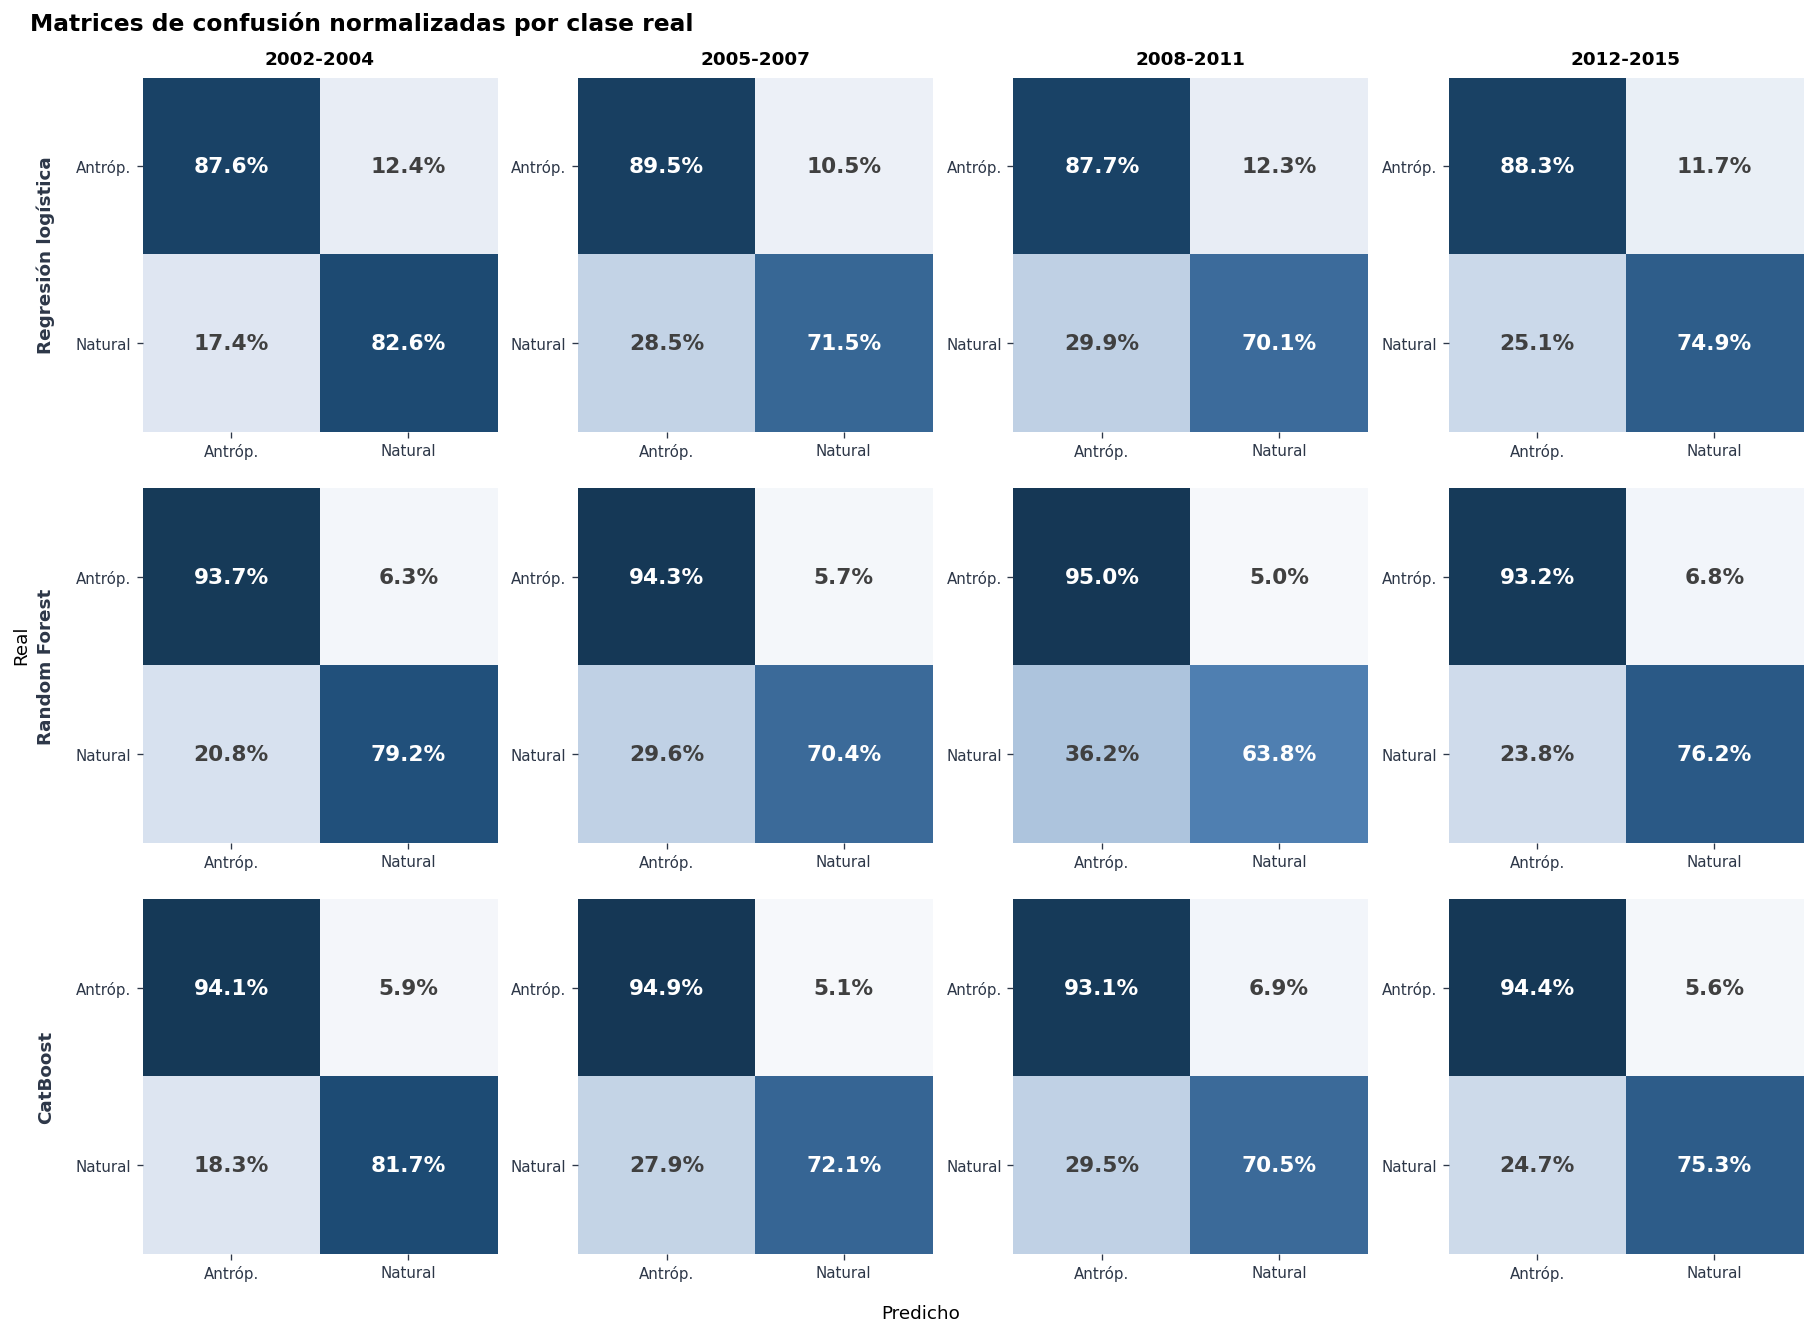

In [14]:
fig, axes = plt.subplots(3, 4, figsize=(15, 11))

for fila, modelo in enumerate(ORDEN):
    for col, L in enumerate(LOTES):
        ax = axes[fila, col]
        r = todos[(todos['Modelo'] == modelo) & (todos['Lote'] == L['nombre'])].iloc[0]
        cm = np.array([[r['Especif.'], 1 - r['Especif.']],
                       [1 - r['Recall'], r['Recall']]]) * 100

        ax.imshow(cm, cmap=SEQ, vmin=0, vmax=100)
        for i in range(2):
            for j in range(2):
                ax.text(j, i, f'{cm[i,j]:.1f}%', ha='center', va='center',
                        fontsize=13, fontweight='bold',
                        color='white' if cm[i,j] > 55 else '#404040')

        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Antróp.', 'Natural'], fontsize=9)
        ax.set_yticklabels(['Antróp.', 'Natural'], fontsize=9)
        ax.grid(visible=False)
        for s in ax.spines.values():
            s.set_visible(False)

        if fila == 0:
            ax.set_title(f"{L['test_ini']}-{L['test_fin']}", fontsize=11, pad=8)
        if col == 0:
            ax.set_ylabel(modelo, fontsize=11, fontweight='bold', labelpad=12)

fig.text(0.5, -0.01, 'Predicho', ha='center', fontsize=11)
fig.text(-0.005, 0.5, 'Real', va='center', rotation=90, fontsize=11)
fig.suptitle('Matrices de confusión normalizadas por clase real',
             x=0.005, ha='left', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{FIGURAS}/matrices_confusion.png')
plt.show()

Las matrices están normalizadas por clase real, así que cada fila suma 100%. La diagonal
muestra el porcentaje de aciertos de cada clase y la fila de abajo es la que importa: cuántos
incendios naturales se detectan.

Los tres modelos clasifican bien la clase antrópica, entre el 87% y el 95%, algo esperable
porque es la clase mayoritaria. La diferencia está en la clase natural. La regresión logística
la detecta peor y con más variación entre lotes, y el Random Forest cae al 63,8% en el lote 3,
el valor más bajo de toda la grilla. CatBoost es el más parejo: se mantiene entre el 71% y el
82% en los cuatro períodos.

También se ve el costo de cada umbral. La regresión logística clasifica más incendios como
naturales, lo que le da más detección pero también más falsos positivos, mientras que los dos
modelos de ensamble son más conservadores.

# Modelo final


Tomo CatBoost entrenado en el último lote, con prueba sobre 2012-2015, que es el período más
reciente y el más parecido a un uso real del modelo. No hace falta volver a entrenarlo: el
modelo, las probabilidades y el umbral ya quedaron guardados en el bucle.

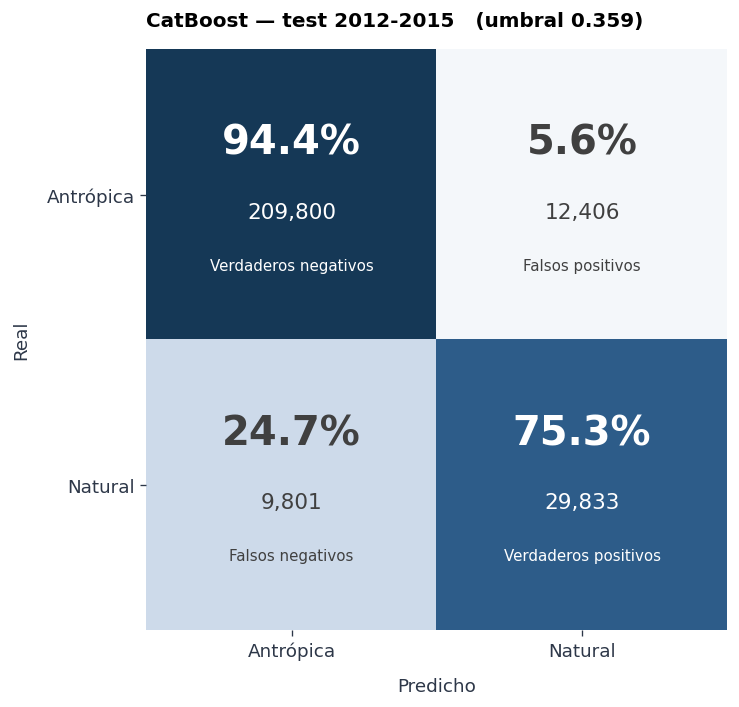

              precision    recall  f1-score   support

   Antrópica     0.9554    0.9442    0.9497    222206
     Natural     0.7063    0.7527    0.7288     39634

    accuracy                         0.9152    261840
   macro avg     0.8308    0.8484    0.8392    261840
weighted avg     0.9177    0.9152    0.9163    261840



In [15]:
LOTE_FINAL = LOTES[-1]['nombre']

modelo_final = ajustados[('CatBoost', LOTE_FINAL)]
y_te, p_te, UMBRAL = probas[('CatBoost', LOTE_FINAL)]
te = datos[LOTE_FINAL]
pred = (p_te >= UMBRAL).astype(int)

cm = confusion_matrix(y_te, pred)
cmp = cm / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(cmp, cmap=SEQ, vmin=0, vmax=100)
etiq = [['Verdaderos negativos', 'Falsos positivos'],
        ['Falsos negativos', 'Verdaderos positivos']]
for i in range(2):
    for j in range(2):
        c = 'white' if cmp[i,j] > 55 else '#404040'
        ax.text(j, i - 0.14, f'{cmp[i,j]:.1f}%', ha='center', fontsize=24, fontweight='bold', color=c)
        ax.text(j, i + 0.08, f'{cm[i,j]:,}', ha='center', fontsize=13, color=c)
        ax.text(j, i + 0.26, etiq[i][j], ha='center', fontsize=9, color=c)

ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Antrópica', 'Natural'], fontsize=11)
ax.set_yticklabels(['Antrópica', 'Natural'], fontsize=11)
ax.set_xlabel('Predicho', fontsize=11, labelpad=10)
ax.set_ylabel('Real', fontsize=11, labelpad=10)
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)

ax.set_title(f'CatBoost — test {LOTES[-1]["test_ini"]}-{LOTES[-1]["test_fin"]}   (umbral {UMBRAL:.3f})',
             loc='left', pad=14)
plt.tight_layout()
plt.show()

print(classification_report(y_te, pred, target_names=['Antrópica','Natural'], digits=4))

Sobre 261.840 incendios de prueba el modelo acierta el 91,4%, con 11.370 falsos positivos y
10.475 falsos negativos. Que los dos tipos de error queden casi iguales es consecuencia de
haber elegido el umbral maximizando F1.

Los números por clase son muy distintos entre sí. La clase antrópica se clasifica bien, con
94,9% de aciertos, mientras que de los incendios naturales el modelo detecta el 75,3%. Uno de
cada cuatro incendios por rayo queda clasificado como humano. Esa asimetría es esperable con
una clase que representa alrededor del 16% de los casos.

In [16]:
filas = []
for u in sorted([0.15, 0.20, 0.25, 0.30, UMBRAL, 0.50, 0.60]):
    pr = (p_te >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pr).ravel()
    filas.append({
        'umbral': round(u, 3),
        'Recall (natural detectado)': round(tp/(tp+fn), 3),
        'Precisión': round(tp/(tp+fp), 3),
        'F1': round(f1_score(y_te, pr), 3),
        'Falsos negativos': fn,
        'Falsos positivos': fp,
    })
pd.DataFrame(filas)

,umbral,Recall (natural detectado),Precisión,F1,Falsos negativos,Falsos positivos
0,0.150,0.845,0.583,0.690,6126,23927
1,0.200,0.825,0.619,0.707,6953,20121
2,0.250,0.804,0.649,0.718,7764,17243
3,0.300,0.782,0.676,0.726,8624,14830
4,0.359,0.753,0.706,0.729,9801,12406
5,0.500,0.669,0.774,0.718,13114,7756
6,0.600,0.597,0.818,0.690,15988,5261


El umbral que maximiza el F1 sobre validación queda alrededor de 0,36, y sobre el conjunto de
prueba cae cerca del punto de equilibrio entre precisión y recall. La tabla muestra qué pasa
si se lo mueve.

El F1 se mantiene casi plano entre 0,25 y 0,50, así que el desempeño global no depende mucho
de dónde se corte. Lo que sí cambia es el tipo de error. Bajando el umbral a 0,15 el modelo
detecta el 84,6% de los incendios naturales, pero clasifica mal 24.076 antrópicos. Subiéndolo
a 0,60 los falsos positivos caen a 5.308, a costa de perder más del 40% de los naturales.

Esa elección no es estadística sino de uso. Si el modelo se usara para completar causas en
registros históricos, conviene un umbral equilibrado. Si se usara para orientar una
investigación, donde el costo de revisar un incendio de más es bajo, convendría bajarlo.

Los valores exactos pueden moverse un poco entre corridas, porque CatBoost entrena en GPU y el
orden de las operaciones en paralelo no es siempre el mismo. Las diferencias son de centésimas
y no afectan las conclusiones.

             Variable  Importancia
        DISCOVERY_DOY    35.629076
            LONGITUDE    18.860446
             LATITUDE    14.247119
                STATE    11.223136
            FIRE_YEAR     7.272666
          OWNER_DESCR     5.724444
NWCG_REPORTING_AGENCY     4.163885
            FIRE_SIZE     2.879228


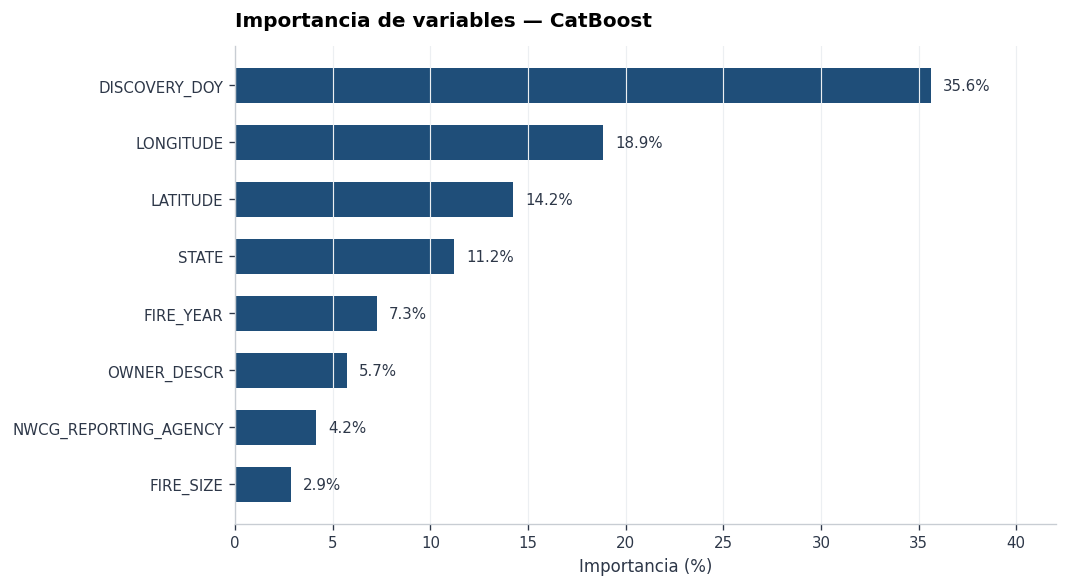

In [17]:
imp = modelo_final.get_feature_importance(prettified=True)
imp.columns = ['Variable', 'Importancia']
print(imp.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp['Variable'], imp['Importancia'], color=AZUL, height=0.62)
for i, v in enumerate(imp['Importancia']):
    ax.text(v + 0.6, i, f'{v:.1f}%', va='center', fontsize=9, color=TEXTO)
ax.invert_yaxis()
ax.set_xlim(0, imp['Importancia'].max() * 1.18)
ax.set_xlabel('Importancia (%)')
ax.grid(axis='y', visible=False)
ax.set_title('Importancia de variables — CatBoost', loc='left', pad=12)
plt.tight_layout()
plt.show()

El día del año es la variable más importante por amplio margen, con casi el 36%. Le siguen
longitud y latitud, y después el estado. Entre fecha y ubicación explican cerca del 80% de la
importancia total.

Esto coincide con lo que mostró el análisis exploratorio: el rayo se concentra en verano y en
el interior del oeste, mientras que las causas humanas se reparten a lo largo del año y siguen
la distribución de la población. El modelo no está aprendiendo algo distinto de lo que se veía
en los gráficos, sino que lo está usando de forma combinada.

La superficie quemada aporta poco, menos del 3%, aunque es una variable que solo se conoce
cuando el incendio ya terminó. Que pese tan poco es una buena noticia para un uso real:
significa que el modelo se apoya casi por completo en información disponible desde el
momento del registro.

El estado y la agencia informante juntos suman alrededor del 15%. Hay que leerlo con cuidado,
porque son las variables que también capturan diferencias de criterio administrativo, no solo
diferencias reales entre territorios. El análisis SHAP permite ver en qué dirección actúan.

## Análisis SHAP

Los valores SHAP (Lundberg y Lee, 2017) descomponen cada predicción individual en la
contribución de cada variable. A diferencia de la importancia, que solo dice cuánto pesa cada
una, acá se ve también la dirección: si un valor alto de una variable empuja la predicción
hacia causa natural o hacia causa antrópica.

El cálculo se hace sobre una muestra de 30.000 registros del conjunto de prueba, porque es
costoso.

/tmp/ipykernel_792/2546783333.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, muestra[FEATS], show=False, max_display=8)


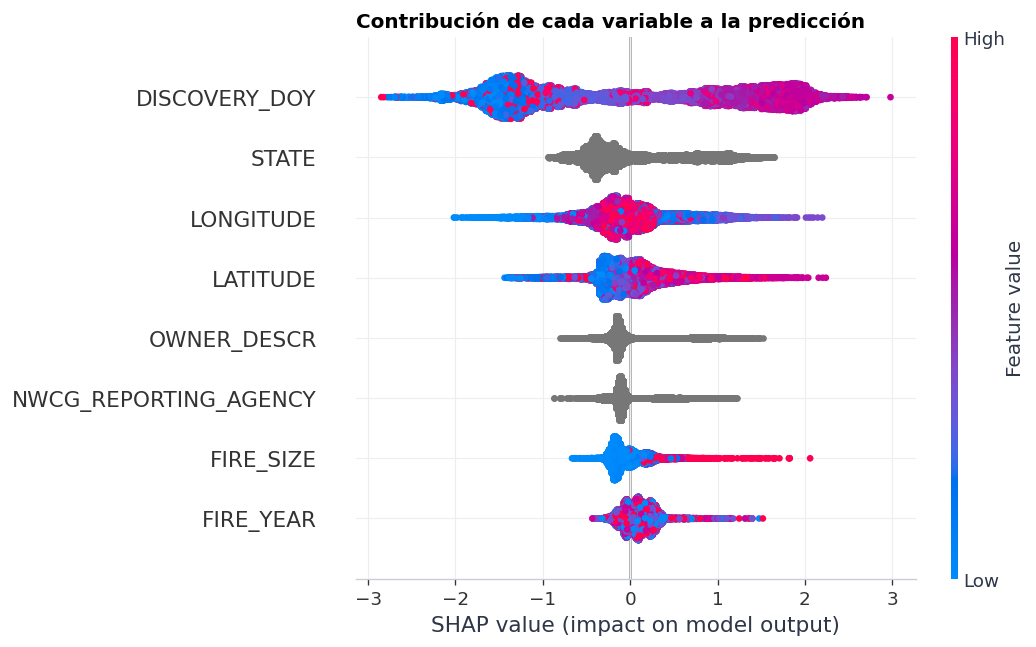

In [18]:

muestra = te.sample(30000, random_state=SEED)
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(muestra[FEATS])

shap.summary_plot(shap_values, muestra[FEATS], show=False, max_display=8)
fig = plt.gcf()
fig.set_size_inches(9, 5.5)
plt.title('Contribución de cada variable a la predicción', loc='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

El día del año es la variable con mayor dispersión, entre -3 y +3, y se ve el patrón esperado:
los valores altos, en rojo, empujan hacia causa natural, y los bajos, en azul, hacia causa
humana. Es la estacionalidad que veíamos en el exploratorio, ahora leída por el modelo.

La longitud tiene el efecto invertido respecto de la latitud. En longitud los valores bajos,
que son los más negativos y corresponden al oeste, empujan hacia natural, mientras que los
altos del este empujan hacia humana. En latitud pasa lo contrario: el norte tira hacia natural.
Las dos juntas reproducen el contraste geográfico del mapa.

La superficie quemada tiene poco peso en la mayoría de los casos, pero su cola a la derecha es
larga y roja: los incendios grandes empujan con fuerza hacia causa natural. Es un efecto que
aparece en pocos registros, por eso su importancia global es baja.

El estado, el propietario y la agencia aparecen en gris porque son categóricas y no tienen un
orden que colorear. Lo que se ve es su dispersión: el estado llega hasta 1,5 en ambas
direcciones, o sea que para algunos estados el efecto es tan fuerte como el de la ubicación.

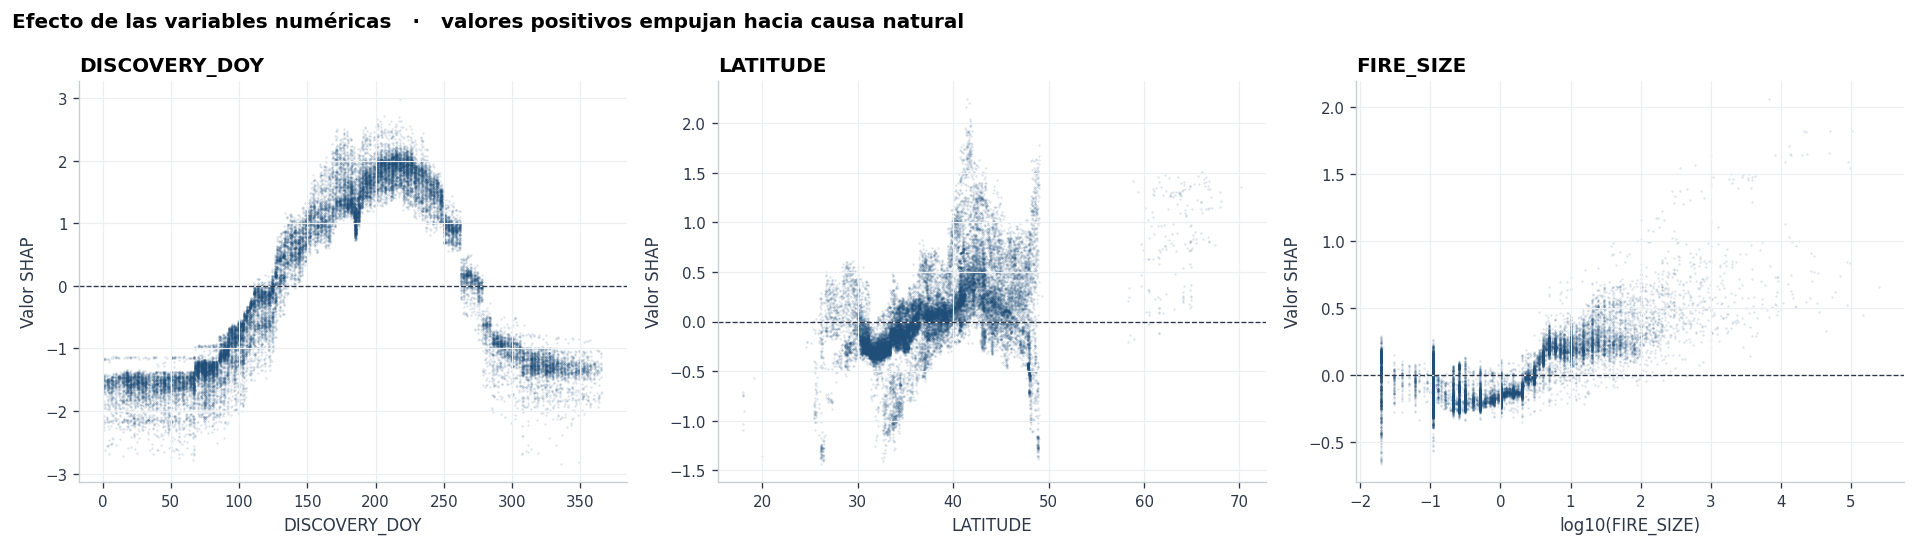

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, var in zip(axes, ['DISCOVERY_DOY', 'LATITUDE', 'FIRE_SIZE']):
    idx = FEATS.index(var)
    x = muestra[var].values
    y = shap_values[:, idx]
    if var == 'FIRE_SIZE':
        x = np.log10(x + 0.01)
        ax.set_xlabel('log10(FIRE_SIZE)')
    else:
        ax.set_xlabel(var)
    ax.scatter(x, y, s=2, alpha=0.15, color=AZUL, linewidths=0)
    ax.axhline(0, color=TEXTO, lw=0.8, ls='--')
    ax.set_ylabel('Valor SHAP')
    ax.set_title(var, loc='left')

fig.suptitle('Efecto de las variables numéricas   ·   valores positivos empujan hacia causa natural',
             x=0.005, ha='left', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Los tres paneles muestran la forma exacta de cada efecto.

El día del año dibuja una campana casi perfecta. Entre enero y abril el aporte es negativo y
plano, alrededor de -1,5, o sea que el modelo descarta el rayo. Cruza el cero cerca del día
120, a fines de abril, y llega al máximo entre los días 200 y 230, que es julio y agosto.
Después cae y vuelve a estabilizarse en negativo desde octubre.

La latitud es más irregular. Hay una caída marcada entre los 30 y los 35 grados, que empuja
hacia causa humana, y un pico entre los 40 y los 48, que empuja hacia natural. Los puntos
sueltos arriba de los 55 grados son Alaska, donde el aporte es siempre positivo.

La superficie quemada casi no aporta por debajo de un acre, donde está la mayoría de los
registros. A partir de ahí el efecto crece de forma sostenida y llega a 1,5 en los incendios
más grandes.

## Curvas ROC y precisión-recall

Las dos curvas comparan los tres modelos sobre el mismo conjunto de prueba, el del último
lote. Las probabilidades salen del bucle de entrenamiento, así que acá no se entrena nada.

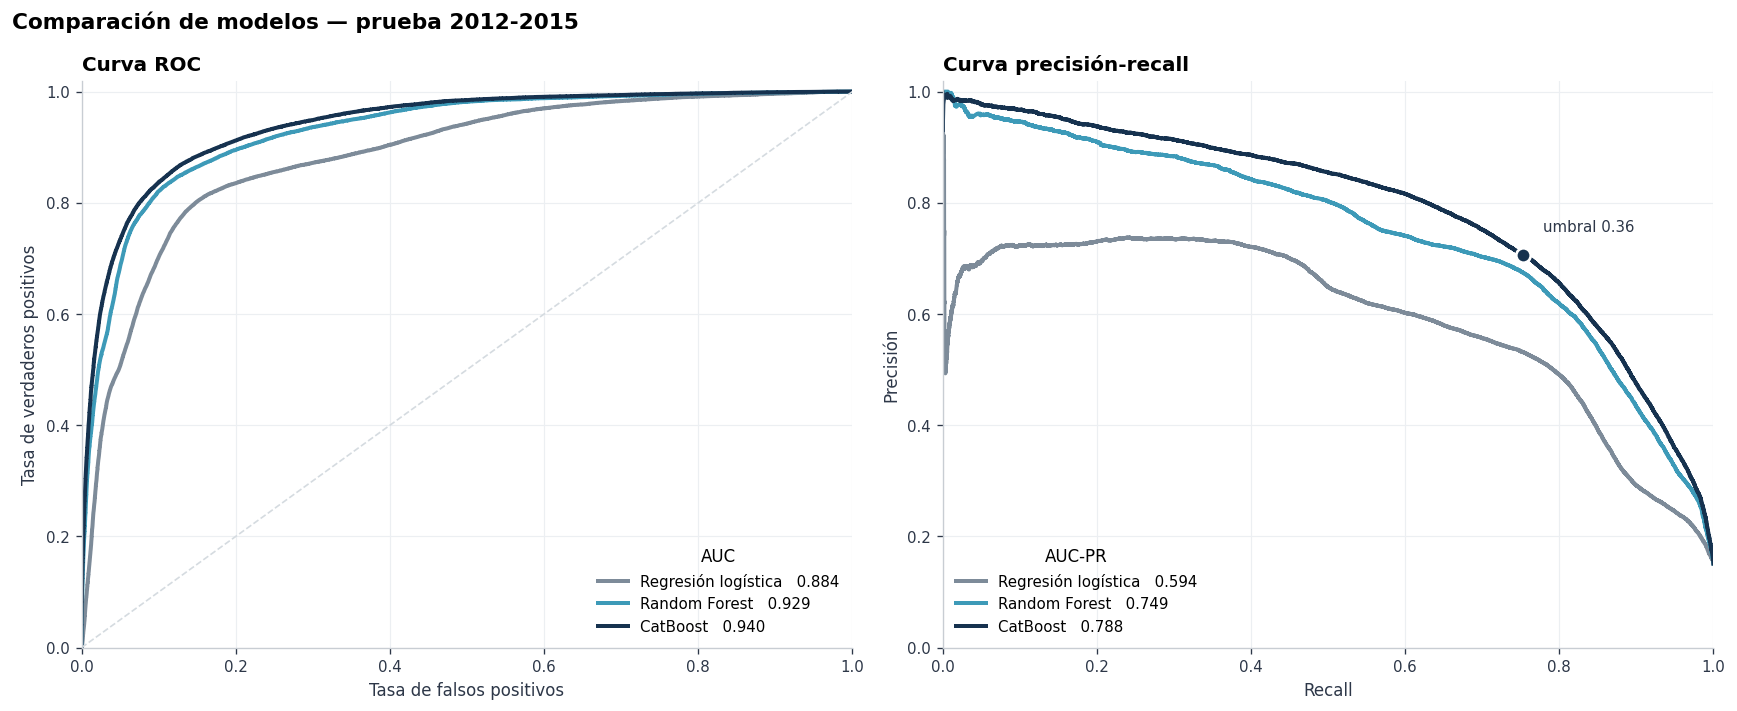

In [20]:
te4 = datos[LOTE_FINAL]
y4 = y_te

curvas = [(nombre, probas[(nombre, LOTE_FINAL)][1], COLOR_MODELO[nombre])
          for nombre in ORDEN]

p_cb = p_te

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6))

ax = axes[0]
for nombre, p, color in curvas:
    fpr, tpr, _ = roc_curve(y4, p)
    ax.plot(fpr, tpr, color=color, lw=2.4,
            label=f'{nombre}   {roc_auc_score(y4, p):.3f}')
ax.plot([0, 1], [0, 1], color='#d5dbe0', lw=1, ls='--')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.set_title('Curva ROC', loc='left')
ax.legend(loc='lower right', title='AUC')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

ax = axes[1]
for nombre, p, color in curvas:
    prec, rec, _ = precision_recall_curve(y4, p)
    ax.plot(rec, prec, color=color, lw=2.4,
            label=f'{nombre}   {average_precision_score(y4, p):.3f}')

rec_u = recall_score(y4, (p_cb >= UMBRAL).astype(int))
prec_u = precision_score(y4, (p_cb >= UMBRAL).astype(int))
ax.scatter([rec_u], [prec_u], s=75, color=MARINO, zorder=5,
           edgecolor='white', linewidth=1.6)
ax.annotate(f'umbral {UMBRAL:.2f}', xy=(rec_u, prec_u),
            xytext=(12, 14), textcoords='offset points', fontsize=9, color=TEXTO)

ax.set_xlabel('Recall')
ax.set_ylabel('Precisión')
ax.set_title('Curva precisión-recall', loc='left')
ax.legend(loc='lower left', title='AUC-PR')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

fig.suptitle(f'Comparación de modelos — prueba {LOTES[-1]["test_ini"]}-{LOTES[-1]["test_fin"]}',
             x=0.005, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Las dos curvas cuentan historias distintas. En la ROC, CatBoost y Random Forest se superponen
casi por completo y la regresión logística queda por debajo, aunque no demasiado lejos. En la
curva precisión-recall las tres se separan con claridad, sobre todo la regresión, que se
estanca alrededor de 0,73 de precisión en todo el rango medio mientras los dos ensambles se
mantienen por encima de 0,80 hasta un recall de 0,6.

Esa diferencia es el argumento a favor de la métrica elegida. La curva ROC usa la tasa de
falsos positivos, que se calcula sobre la clase mayoritaria y por eso se mantiene baja aunque
el modelo se equivoque bastante sobre la minoritaria. La curva precisión-recall solo mira la
clase positiva, así que refleja mejor el problema real.

El punto marcado sobre la curva de CatBoost es el umbral elegido, con recall 0,75 y precisión
0,71. Está justo antes del tramo donde la curva se derrumba: a partir de un recall de 0,8 la
precisión cae de forma abrupta, y eso confirma que subir la detección de incendios naturales
más allá de ese punto sale caro.

# Análisis de errores

Se busca la distribución de los errores según la ubicación, el momento del año y la magnitud
del incendio, con el objetivo de identificar si existen condiciones sistemáticas en las que el
modelo pierde capacidad predictiva.

In [21]:
err = te4.copy()
err['proba'] = p_cb
err['pred'] = (p_cb >= UMBRAL).astype(int)
err['acierto'] = (err['pred'] == err['ES_NATURAL']).astype(int)
err['tipo_error'] = np.select(
    [(err['ES_NATURAL']==1) & (err['pred']==0),
     (err['ES_NATURAL']==0) & (err['pred']==1)],
    ['Falso negativo', 'Falso positivo'], default='Correcto')

print(f"Aciertos: {err['acierto'].mean()*100:.2f}%")
print()
print(err['tipo_error'].value_counts().to_string())

Aciertos: 91.52%

tipo_error
Correcto          239633
Falso positivo     12406
Falso negativo      9801


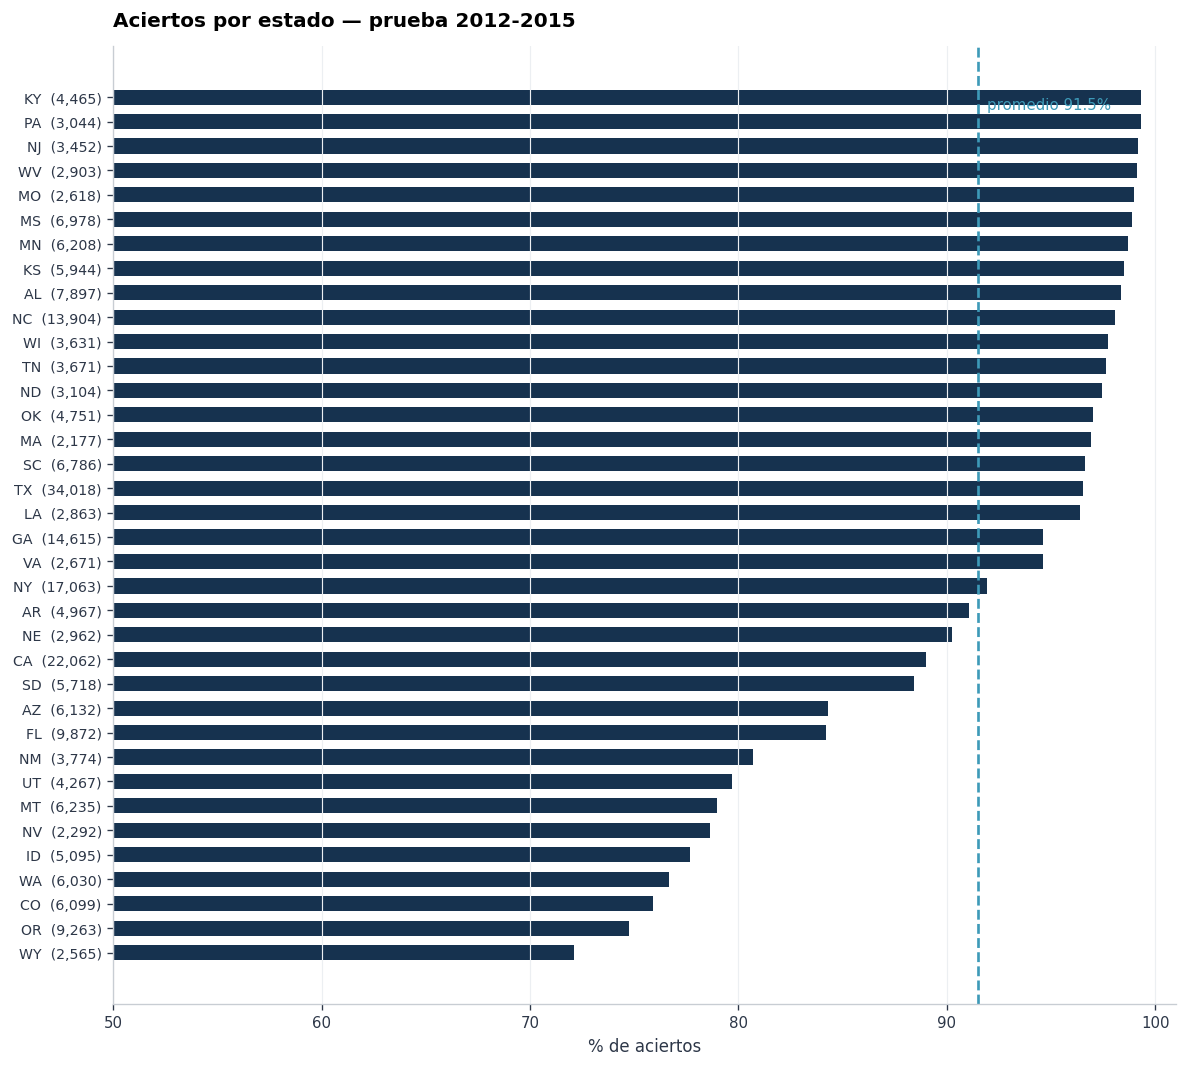

In [22]:
est = err.groupby('STATE').agg(
    n=('acierto','size'), acc=('acierto','mean'), nat=('ES_NATURAL','mean')).reset_index()
est = est[est['n'] > 2000].sort_values('acc')

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(len(est)), est['acc']*100, color=MARINO, height=0.62)
ax.set_yticks(range(len(est)))
ax.set_yticklabels([f"{s}  ({n:,})" for s, n in zip(est['STATE'], est['n'])], fontsize=8.5)
ax.axvline(err['acierto'].mean()*100, color=CELESTE, lw=1.6, ls='--')
ax.text(err['acierto'].mean()*100 + 0.4, len(est)-1.5,
        f"promedio {err['acierto'].mean()*100:.1f}%", fontsize=9, color=CELESTE)
ax.set_xlim(50, 101)
ax.set_xlabel('% de aciertos')
ax.grid(axis='y', visible=False)
ax.set_title('Aciertos por estado — prueba 2012-2015', loc='left', pad=12)
plt.tight_layout()
plt.show()

Los aciertos por estado tienen un rango enorme, de casi el 99% en Kentucky, Pensilvania y
Nueva Jersey al 72% en Wyoming. El corte no es aleatorio: arriba del promedio están los
estados del este y del sur, y abajo están todos los del oeste, con Wyoming, Oregón, Colorado,
Washington y Nevada en el fondo.

La explicación es la proporción de incendios naturales de cada estado. En el este, donde casi
todo es humano, el modelo acierta sin esfuerzo. En el oeste, donde el rayo representa una parte
importante de los incendios, tiene que decidir de verdad, y ahí aparecen los errores. O sea que
el modelo no falla en lugares arbitrarios: falla donde la tarea es difícil.

Eso tiene una consecuencia para el uso del modelo. Si se lo aplicara para completar causas
faltantes, sería más confiable en los estados del este que en los del oeste, que son
justamente los que más incendios naturales tienen.

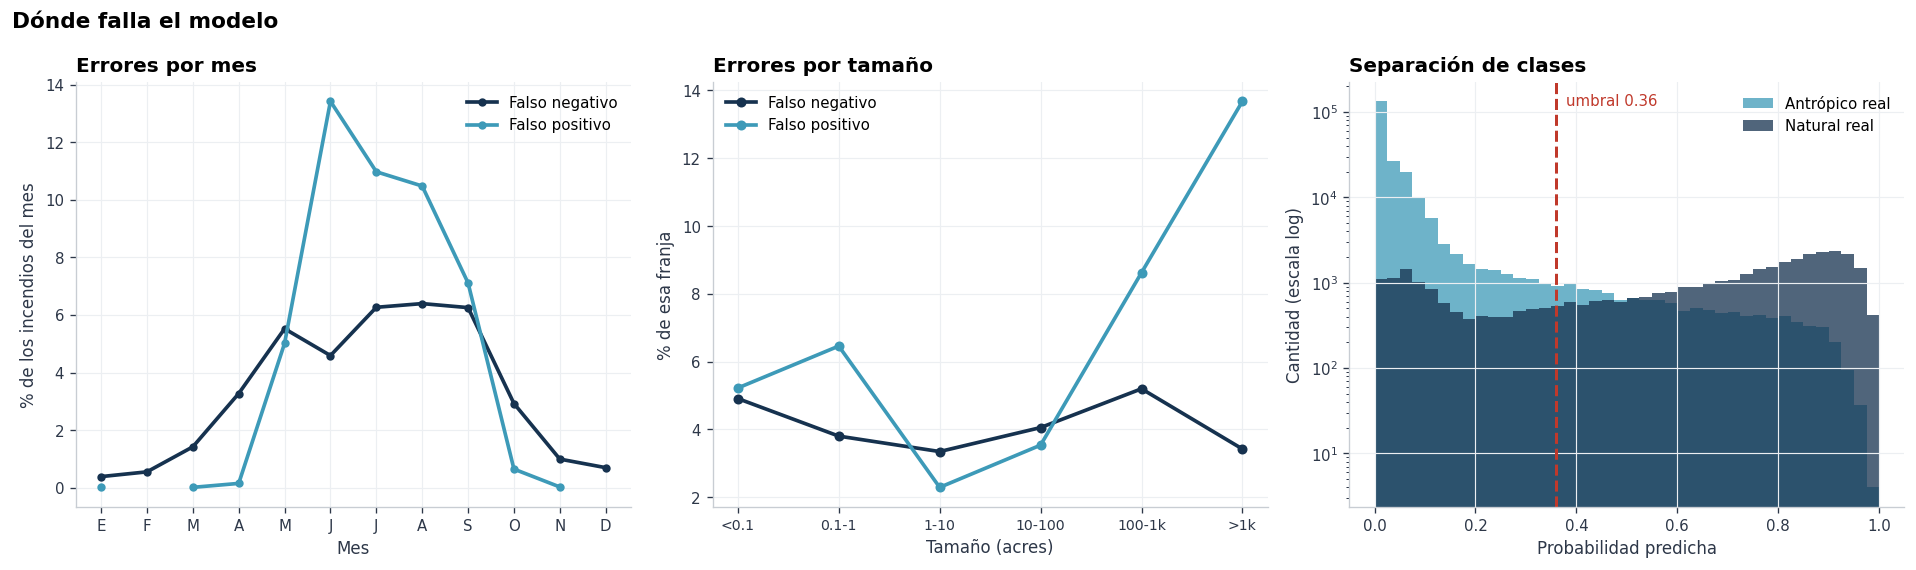

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
m = pd.to_datetime(err['DISCOVERY_DOY'], format='%j').dt.month
for tipo, color in [('Falso negativo', MARINO), ('Falso positivo', CELESTE)]:
    sub = err[err['tipo_error']==tipo]
    tasa = sub.groupby(pd.to_datetime(sub['DISCOVERY_DOY'], format='%j').dt.month).size() / err.groupby(m).size() * 100
    ax.plot(tasa.index, tasa.values, color=color, lw=2.2, marker='o', ms=4, label=tipo)
ax.set_xticks(range(1,13))
ax.set_xticklabels(['E','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_xlabel('Mes'); ax.set_ylabel('% de los incendios del mes')
ax.set_title('Errores por mes', loc='left')
ax.legend()

ax = axes[1]
cl = pd.crosstab(pd.cut(np.log10(err['FIRE_SIZE']+0.01), bins=[-3,-1,0,1,2,3,7],
                        labels=['<0.1','0.1-1','1-10','10-100','100-1k','>1k']),
                 err['tipo_error'], normalize='index') * 100
for tipo, color in [('Falso negativo', MARINO), ('Falso positivo', CELESTE)]:
    if tipo in cl:
        ax.plot(range(len(cl)), cl[tipo], color=color, lw=2.2, marker='o', ms=5, label=tipo)
ax.set_xticks(range(len(cl))); ax.set_xticklabels(cl.index, fontsize=8.5)
ax.set_xlabel('Tamaño (acres)'); ax.set_ylabel('% de esa franja')
ax.set_title('Errores por tamaño', loc='left')
ax.legend()

ax = axes[2]
bins = np.linspace(0, 1, 41)
ax.hist(err[err['ES_NATURAL']==0]['proba'], bins=bins, color=CELESTE, alpha=0.75, label='Antrópico real')
ax.hist(err[err['ES_NATURAL']==1]['proba'], bins=bins, color=MARINO, alpha=0.75, label='Natural real')
ax.axvline(UMBRAL, color='#c0392b', lw=1.8, ls='--')
ax.text(UMBRAL+0.02, ax.get_ylim()[1]*0.85, f'umbral {UMBRAL:.2f}', fontsize=9, color='#c0392b')
ax.set_yscale('log')
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Cantidad (escala log)')
ax.set_title('Separación de clases', loc='left')
ax.legend()

fig.suptitle('Dónde falla el modelo', x=0.005, ha='left', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Los tres paneles refuerzan la misma idea.

Los errores se concentran en verano. En junio, el 13% de los incendios del mes son falsos
positivos, contra menos del 1% entre noviembre y abril. Es el período donde conviven las dos
causas: en invierno el modelo puede descartar el rayo casi sin riesgo, pero en plena temporada
de tormentas cualquier incendio es candidato.

Los errores por tamaño muestran un salto en la franja de más de mil acres, donde el 13% son
falsos positivos. Coincide con lo que mostró el SHAP: el tamaño empuja fuerte hacia causa
natural, así que un incendio humano que creció mucho tiene grandes chances de ser clasificado
como rayo.

La separación de clases es el panel más favorable. Las dos distribuciones se apilan en
extremos opuestos, con los antrópicos concentrados cerca de 0 y los naturales cerca de 1. La
zona intermedia, entre 0,2 y 0,6, tiene poco volumen en escala logarítmica, que es donde el
modelo no logra decidir.

# Conclusiones

Con ocho variables del propio registro, CatBoost alcanza un AUC-ROC de 0,930 y un AUC-PR de
0,782 promediando los cuatro lotes, evaluado siempre sobre años posteriores a los de
entrenamiento. Supera a la regresión logística por 5,5 y 17 puntos respectivamente, así que la
complejidad adicional se justifica, y le gana al Random Forest sobre todo en AUC-PR.

El modelo se apoya en la fecha y la ubicación, que juntas explican cerca del 80% de la
importancia. Eso es una buena señal para un uso real, porque son datos disponibles desde el
momento en que se registra el incendio, y además coincide con lo que mostraba el análisis
exploratorio.

Los errores tienen un patrón claro: se concentran en verano, en los estados del oeste y en los
incendios grandes. Son las condiciones donde las dos causas conviven, así que el modelo falla
donde el problema es difícil y no de forma arbitraria. La contracara es que resulta menos
confiable justamente en las regiones con más incendios naturales.